In [1]:
import scanpy as sc
import celltypist
from celltypist import models

In [2]:
sc.settings.verbosity = 0
sc.settings.set_figure_params(
    dpi=80,
    facecolor="white",
    frameon=False,
)

#### Load data

In [3]:
adata = sc.read_h5ad('integrated.h5ad')
print(adata.shape)
print(adata.obs_names.is_unique)
len(adata.obs_names[adata.obs_names.duplicated()]) 

(33564, 19958)
False


108

In [4]:
# Remove duplicated cell barcodes, keeping the first occurrence
adata = adata[~adata.obs_names.duplicated()].copy()

In [5]:
print(adata.shape)
print(adata.obs_names.is_unique)
len(adata.obs_names[adata.obs_names.duplicated()]) 

(33456, 19958)
True


0

In [6]:
# Expression matrix (adata.X) is pre-processed (as required for celltypist)
# Expression is log1p normalised to 10,000 counts per cell
adata.X.expm1().sum(axis = 1)

matrix([[10000.001],
        [10000.   ],
        [ 9999.999],
        ...,
        [10000.001],
        [10000.   ],
        [10000.001]], dtype=float32)

In [7]:
# Pre-assigned cell type labels are present in the data
# We compare this to the predicted labels from CellTypist later
adata.obs[["cell_type"]].head(3) # there

,cell_type
AAACCCAAGCCTCTGG-1,Alveolar macrophages
AAACCCAAGCGACTTT-1,Endothelial cells
AAACCCAAGCGTATGG-1,Endothelial cells


#### Assign cell type labels using a CellTypist built-in model

In [8]:
md = models.models_description()
md.head(5)

👉 Detailed model information can be found at `https://www.celltypist.org/models`


,model,description
0,Immune_All_Low.pkl,immune sub-populations combined from 20 tissue...
1,Immune_All_High.pkl,immune populations combined from 20 tissues of...
2,Adult_COVID19_PBMC.pkl,peripheral blood mononuclear cell types from C...
3,Adult_CynomolgusMacaque_Hippocampus.pkl,cell types from the hippocampus of adult cynom...
4,Adult_Human_MTG.pkl,cell types and subtypes (10x-based) from the a...


In [ ]:
# because I used  lung data
lung_models = md[ md['description'].str.contains('lung', case=False) | md['model'].str.contains('Lung', case=False) ]
lung_models

,model,description
15,Autopsy_COVID19_Lung.pkl,cell types from the lungs of 16 SARS-CoV-2 inf...
17,COVID19_Immune_Landscape.pkl,immune subtypes from lung and blood of COVID-1...
19,Cells_Fetal_Lung.pkl,cell types from human embryonic and fetal lungs
22,Cells_Lung_Airway.pkl,cell populations from scRNA-seq of five locati...
44,Human_IPF_Lung.pkl,"cell types from idiopathic pulmonary fibrosis,..."
46,Human_Lung_Atlas.pkl,integrated Human Lung Cell Atlas (HLCA) combin...
47,Human_PF_Lung.pkl,cell types from different forms of pulmonary f...
49,Lethal_COVID19_Lung.pkl,cell types from the lungs of individuals who d...
54,Nuclei_Lung_Airway.pkl,cell populations from snRNA-seq of five locati...


In [13]:
# specifying the model name directly is recommended

predictions = celltypist.annotate(
    adata,
    model='Human_Lung_Atlas.pkl',
    majority_voting=True,
    over_clustering='leiden_0_25'     
)


🔬 Input data has 33456 cells and 19958 genes
🔗 Matching reference genes in the model
🧬 4722 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
🗳️ Majority voting the predictions
✅ Majority voting done!


In [16]:
predictions.predicted_labels

,predicted_labels,over_clustering,majority_voting
AAACCCAAGCCTCTGG-1,Interstitial Mph perivascular,2,Classical monocytes
AAACCCAAGCGACTTT-1,EC general capillary,1,EC general capillary
AAACCCAAGCGTATGG-1,EC arterial,1,EC general capillary
AAACCCACAAGTAGTA-1,Adventitial fibroblasts,5,Alveolar fibroblasts
AAACCCACACACCGAC-1,Peribronchial fibroblasts,5,Alveolar fibroblasts
...,...,...,...
TTTGTTGCACATTCGA-1,CD4 T cells,0,CD4 T cells
TTTGTTGCACCAGCCA-1,EC arterial,1,EC general capillary
TTTGTTGCAGGACGAT-1,EC venous systemic,1,EC general capillary
TTTGTTGGTCTATGAC-1,AT2,13,AT2


In [ ]:
# Get an `AnnData` with predicted labels embedded into the cell metadata columns.
adata_celltypist = predictions.to_adata()
adata_celltypist.obs.head()

,revised_prediction,sample,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,_scvi_batch,_scvi_labels,leiden,leiden_0_25,_scvi_raw_norm_scaling,cell_type,predicted_labels,over_clustering,majority_voting,conf_score
AAACCCAAGCCTCTGG-1,singlet,donor1,4154,17016.0,0.0,0.0,2261.0,13.287494,0,0,2,2,0.590633,Alveolar macrophages,Interstitial Mph perivascular,2,Classical monocytes,0.999272
AAACCCAAGCGACTTT-1,singlet,donor1,865,1536.0,0.0,0.0,103.0,6.705729,0,0,1,1,6.540222,Endothelial cells,EC general capillary,1,EC general capillary,0.998419
AAACCCAAGCGTATGG-1,singlet,donor1,383,573.0,0.0,0.0,54.0,9.424084,0,0,1,1,17.482517,Endothelial cells,EC arterial,1,EC general capillary,0.702243
AAACCCACAAGTAGTA-1,singlet,donor1,510,772.0,0.0,0.0,95.0,12.305699,0,0,4,5,13.003901,Fibroblasts,Adventitial fibroblasts,5,Alveolar fibroblasts,0.018940
AAACCCACACACCGAC-1,singlet,donor1,2110,4830.0,0.0,0.0,613.0,12.691511,0,0,4,5,2.083333,Fibroblasts,Peribronchial fibroblasts,5,Alveolar fibroblasts,0.997865


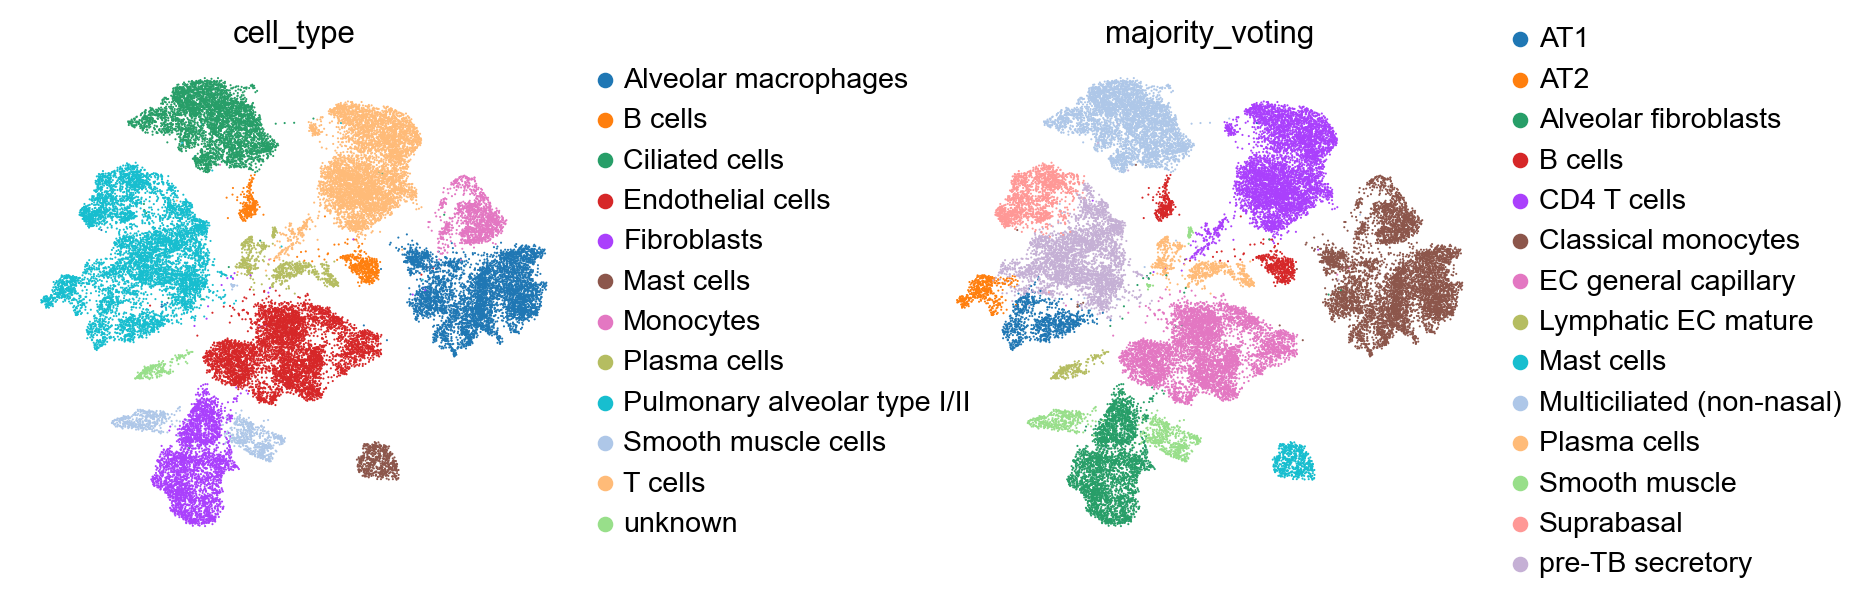

In [28]:
sc.pl.umap(adata_celltypist, 
           color=['cell_type', 'majority_voting'], 
           wspace=0.5, 
           ncols=2)

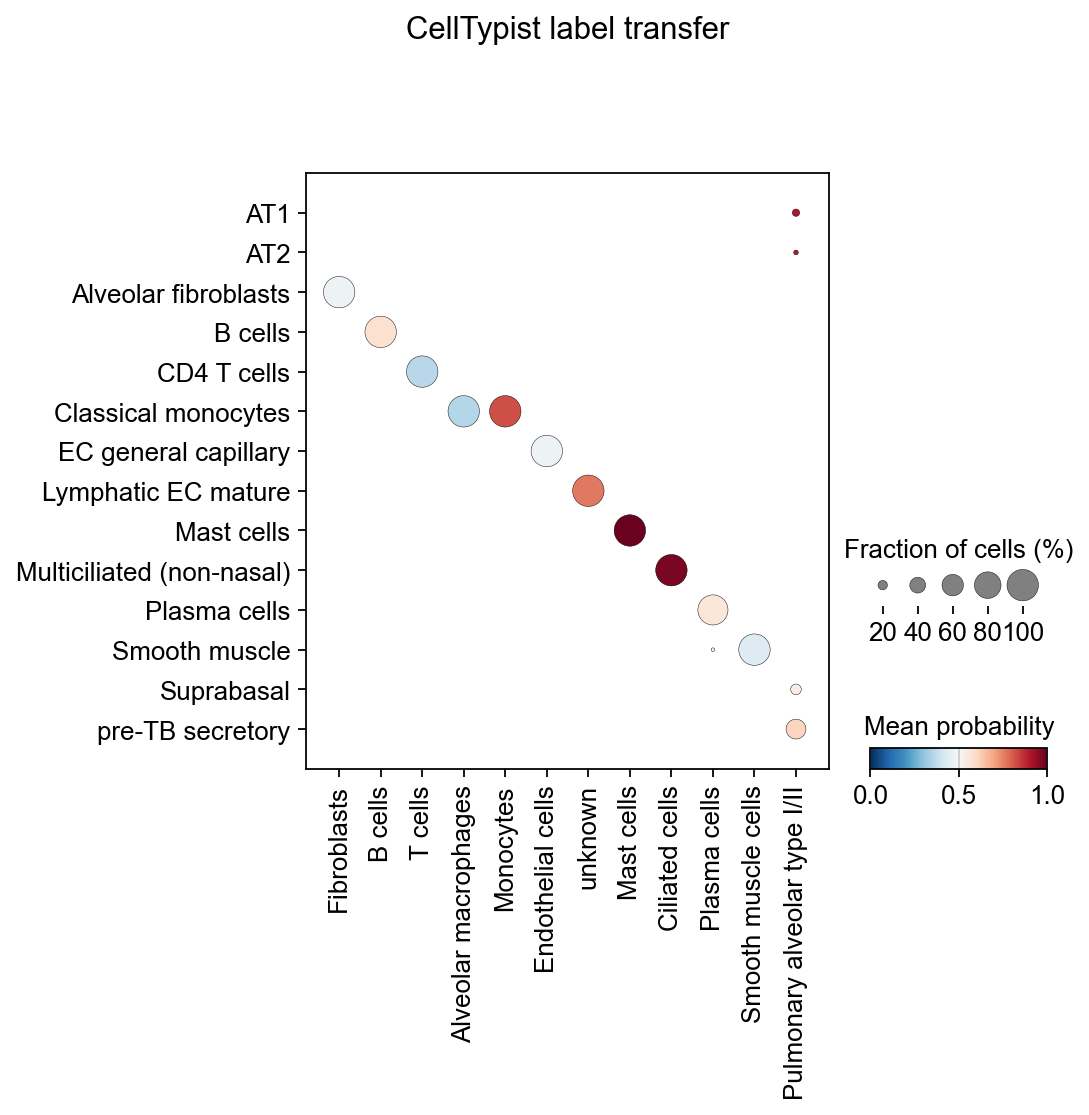

In [29]:
celltypist.dotplot(predictions, use_as_reference = 'cell_type', use_as_prediction = 'majority_voting')